# Quick start

In [2]:
# @title Install AlphaGenome

# @markdown Run this cell to install AlphaGenome.
from IPython.display import clear_output
! pip install alphagenome
clear_output()

## Imports

In [3]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd

## Predict outputs for a DNA sequence

AlphaGenome is a model that makes predictions from DNA sequences. Let's load it
up:

In [4]:
dna_model = dna_client.create(colab_utils.get_api_key())

The model can make predictions for the following
[output types](https://www.alphagenomedocs.com/exploring_model_metadata.html):

In [5]:
[output.name for output in dna_client.OutputType]

['ATAC',
 'CAGE',
 'DNASE',
 'RNA_SEQ',
 'CHIP_HISTONE',
 'CHIP_TF',
 'SPLICE_SITES',
 'SPLICE_SITE_USAGE',
 'SPLICE_JUNCTIONS',
 'CONTACT_MAPS',
 'PROCAP']

AlphaGenome predicts multiple 'tracks' per output type, covering a wide variety
of tissues and cell-types. However, predictions can be made efficiently for
subsets of interest.

Here is how to make DNase-seq predictions (as specified by `OutputType`) in a
subset of tracks corresponding to lung tissue (as specified by `ontology_terms`)
for a DNA sequence of length 1Mb:

*Note: We use ontology terms from standardized biological sources like UBERON
(for anatomy) and the Cell Ontology (CL) to provide consistent and widely
recognized classifications for tissue and cell types.*

In [6]:
output = dna_model.predict_sequence(
    sequence='GATTACA'.center(
        dna_client.SEQUENCE_LENGTH_1MB, 'N'
    ),  # Pad to valid sequence length.
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0002048'],  # Lung.
)

The `output` object contains predictions for all the different requested output
types (in this case, only output type `DNASE`). Predictions for genomic tracks
are stored inside a `TrackData` object:

In [7]:
dnase = output.dnase
type(dnase)

alphagenome.data.track_data.TrackData

In [8]:
print(dnase.values.shape)

dnase.values

(1048576, 1)


array([[0.00187683],
       [0.00177765],
       [0.00177765],
       ...,
       [0.0019989 ],
       [0.00292969],
       [0.0039978 ]], dtype=float32)

And the corresponding metadata describing each of the tracks is stored in
`.metadata`:

In [9]:
dnase.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,data_source,endedness,genetically_modified,nonzero_mean
0,UBERON:0002048 DNase-seq,.,DNase-seq,UBERON:0002048,lung,tissue,embryonic,encode,paired,False,0.427505


In this case, there is only one output track, so the track metadata returns only
1 row.

The track metadata is especially useful when requesting predictions for multiple
tissues or cell-types, and when dealing with stranded assays (which are assays
with separate readouts for the two DNA strands, such as CAGE and RNA-seq):

In [10]:
output = dna_model.predict_sequence(
    sequence='GATTACA'.center(
        dna_client.SEQUENCE_LENGTH_1MB, 'N'
    ),  # Pad to valid sequence length.
    requested_outputs=[
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
    ],
    ontology_terms=[
        'UBERON:0002048',  # Lung.
        'UBERON:0000955',  # Brain.
    ],
)

print(f'DNASE predictions shape: {output.dnase.values.shape}')
print(f'CAGE predictions shape: {output.cage.values.shape}')

DNASE predictions shape: (1048576, 2)
CAGE predictions shape: (1048576, 4)


Notice that in this example, we requested predictions for 2 assays and 2
ontology terms simultaneously.

The CAGE track metadata describes the strand and tissue of each of the 4
predicted tracks (2 per DNA strand):

In [11]:
output.cage.metadata

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,data_source,nonzero_mean
0,hCAGE UBERON:0000955,+,hCAGE,UBERON:0000955,brain,tissue,fantom,28.432245
1,hCAGE UBERON:0002048,+,hCAGE,UBERON:0002048,lung,tissue,fantom,30.655853
2,hCAGE UBERON:0000955,-,hCAGE,UBERON:0000955,brain,tissue,fantom,28.432245
3,hCAGE UBERON:0002048,-,hCAGE,UBERON:0002048,lung,tissue,fantom,30.655853


See the
[output metadata documentation](https://www.alphagenomedocs.com/exploring_model_metadata.html)
for more information on the output types and output shapes. For the mapping
between tissue names (e.g. 'brain' -> 'UBERON:0000955') and ontology terms, see
this [tutorial](tissue_ontology_mapping.ipynb).

## Predict outputs for a genome interval (reference genome)

For convenience, you can also directly make predictions for a human reference
genome sequence specified by a **genomic interval**. For example, let's predict
RNA-seq for tissue 'Right liver lobe' in a 1MB region of Chromosome 19 around
the gene *CYP2B6*, which encodes an enzyme involved in drug metabolism, and is
primarily expressed in the liver.

We first load up a GTF file containing gene and transcript locations as
annotated by GENCODE (more information on GTF format
[here](https://www.gencodegenes.org/pages/data_format.html)):

In [12]:
# The GTF file contains information on the location of all trancripts.
# Note that we use genome assembly hg38 for human.
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Set up transcript extractors using the information in the GTF file.
# Mane select transcripts consists of of one curated transcript per locus.
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

And then fetch the gene's location as a `genome.Interval` object by passing
either its `gene_symbol` (HGNC naming convention) or ENSEMBL `gene_id`:

In [13]:
interval = gene_annotation.get_gene_interval(gtf, gene_symbol='CYP2B6')
interval

Interval(chromosome='chr19', start=40991281, end=41018398, strand='+', name='CYP2B6')

We can resize it to a length compatible with the model:

In [14]:
interval = interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

The `.resize()` method adjusts the interval to the specified width by expanding
(or contracting) around its original center. Note that
`dna_model.predict_interval()` interprets this resizing as an expansion of the
actual genomic sequence rather than padding tokens.

In [15]:
interval.width

1048576

See the
[essential commands documentation](https://www.alphagenomedocs.com/colabs/essential_commands.html)
for more handy commands like `resize`.

Note that AlphaGenome supports the following input sequence lengths:

In [16]:
dna_client.SUPPORTED_SEQUENCE_LENGTHS.keys()

dict_keys(['SEQUENCE_LENGTH_16KB', 'SEQUENCE_LENGTH_100KB', 'SEQUENCE_LENGTH_500KB', 'SEQUENCE_LENGTH_1MB'])

We can now make predictions using our interval:

In [17]:
output = dna_model.predict_interval(
    interval=interval,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=['UBERON:0001114'],
)  # Right liver lobe.

output.rna_seq.values.shape

(1048576, 3)

In general, you can have multiple tracks for a given ontology term. In this
case, we have 3 RNA-seq tracks for the tissue "Right liver lobe".

Let's visualise these predictions. It's helpful visualise gene transcripts
alongside the predicted tracks, so we extract them here:

In [18]:
transcripts = transcript_extractor.extract(interval)
print(f'Extracted {len(transcripts)} transcripts in this interval.')

Extracted 28 transcripts in this interval.


We also provide a
[visualization basics guide](https://www.alphagenomedocs.com/visualization_library_basics.html)
that integrates nicely with `TrackData` and other objects returned by the model
API.

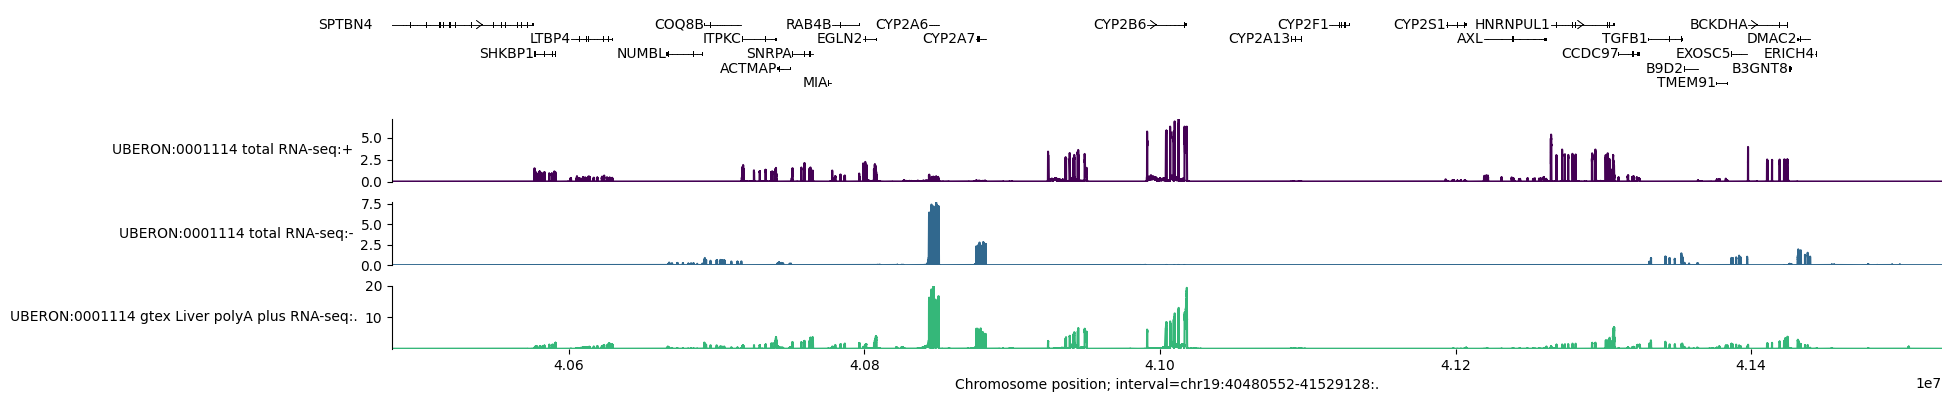

In [19]:
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.Tracks(output.rna_seq),
    ],
    interval=output.rna_seq.interval,
)

plt.show()

This plot visualises the 3 predicted RNA-seq tracks and also marks the location
of the MANE select transcript per gene in the 1MB region.

We can zoom in to the middle of the plot by resizing the interval:

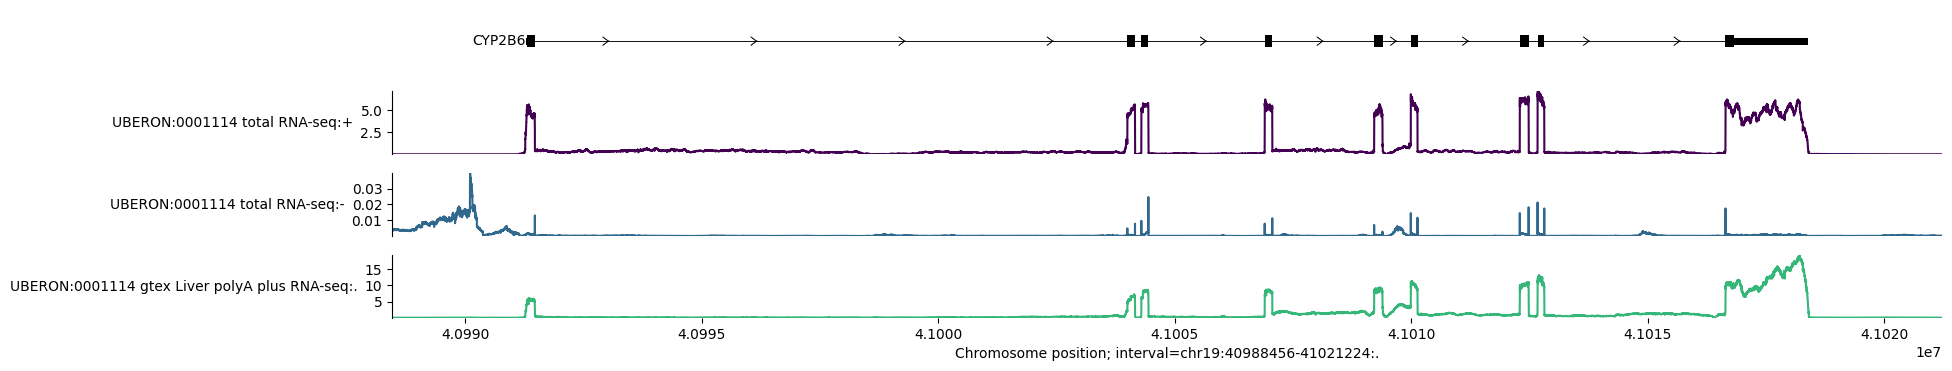

In [20]:
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(
            transcripts, fig_height=0.1
        ),
        plot_components.Tracks(output.rna_seq),
    ],
    interval=output.rna_seq.interval.resize(2**15),
)

plt.show()

You can see here that predicted RNA-seq values are nicely aligned with the
location of exons, and that the predictions are stranded – the predicted values
are much higher for the positive strand, where the gene is located. We see that
the *CYP2B6* gene is on the positive strand since the arrows in the transcript
go from left to right.

For more detail on the visualization library, please refer to the
[visualization basics guide](https://www.alphagenomedocs.com/visualization_library_basics.html)
and
[library documentation](https://www.alphagenomedocs.com/api/visualization.html).

## Predict variant effects

We can predict the effect of a variant on a specific output type and tissue by
making predictions for the reference (REF) and alternative (ALT) allele
sequences.

We specify the variant by defining a `genome.Variant` object. The specific
variant below is a known variant affecting gene expression in colon tissue:

In [21]:
variant = genome.Variant(
    chromosome='chr2',
    position=197402110,
    reference_bases='T',  # Can differ from the true reference genome base.
    alternate_bases='C',
)

Next, we define the interval over which to make the REF and ALT predictions. A
quick way to get a `genome.Interval` from a `genome.Variant` is by calling
`.reference_interval`, which we can resize to a model-compatible sequence
length:

In [22]:
interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

We then use `predict_variant` to get the REF and ALT RNA-seq predictions in the
interval for "Colon - Transverse" tissue (`UBERON:0001157`):

We can plot the predicted REF and ALT values as a single plot and zoom in on the
affected gene to better visualise the variant's effect on gene expression:

We see that the ALT allele (base 'C' at position 36201698) is associated with
both lower expression and an exon skipping event in the *APOL4* gene on the
negative strand. Note that we can ignore the uppermost line plot which shows a
very minimal predicted amount of expression on the positive DNA strand (check
the y axis scales). It is possible to adjust the y axes limits, see
[visualization basics](https://www.alphagenomedocs.com/visualization_library_basics.html#visualization-library-basics)
and
[library documentation](https://www.alphagenomedocs.com/api/visualization.html).

## Scoring the effect of a genetic variant

Scoring the effect of a genetic variant involves making predictions for the REF
and ALT sequences and aggregating the track signal. This is implemented in
`score_variant`, which uses specific `variant_scorer` configs for aggregation.

We provide a set of recommended variant scoring configurations as a dictionary
(`variant_scorers.RECOMMENDED_VARIANT_SCORERS`), covering all output types,
which we have assessed for their performance at domain-specific tasks. See the
[variant scoring documentation](https://www.alphagenomedocs.com/variant_scoring.html)
for more information. Here is a quick demo:

In [ ]:
variant_scores = dna_model.score_variant(
    interval=interval,
    variant=variant,
    variant_scorers=list(variant_scorers.RECOMMENDED_VARIANT_SCORERS.values()),
)

df_scores = variant_scorers.tidy_scores(variant_scores)

df_scores["abs_quantile_score"] = df_scores["quantile_score"].abs()

df_scores.sort_values("abs_quantile_score", ascending=False).head(30)

In [ ]:
scores = df_scores.copy()

# Strength of predicted effect, ignoring direction
scores["abs_quantile_score"] = scores["quantile_score"].abs()

# Shorten scorer names for cleaner plots
scores["scorer_short"] = (
    scores["variant_scorer"]
    .astype(str)
    .str.replace(r"\(.*", "", regex=True)
)

# Remove ActiveScorer rows for REF-vs-ALT interpretation
# These are more about allele activity than variant effect direction.
effect_scores = scores[
    ~scores["scorer_short"].str.contains("ActiveScorer", na=False)
].copy()

effect_scores.sort_values("abs_quantile_score", ascending=False).head(20)

1

In [ ]:
#Plot 1
top_n = 20

top_effects = (
    effect_scores
    .sort_values("abs_quantile_score", ascending=False)
    .head(top_n)
    .copy()
)

top_effects["plot_label"] = (
    top_effects["output_type"].astype(str)
    + " | "
    + top_effects["gene_name"].fillna("non-gene track").astype(str)
    + " | "
    + top_effects["biosample_name"].fillna("").astype(str)
)

top_effects = top_effects.sort_values("abs_quantile_score")

plt.figure(figsize=(10, 8))
plt.barh(top_effects["plot_label"], top_effects["quantile_score"])
plt.axvline(0, linewidth=1)
plt.xlabel("Quantile score")
plt.ylabel("")
plt.title(f"Top predicted effects for {variant.name}")
plt.tight_layout()
plt.show()

,gene_id,strand,gene_name,gene_type
0,ENSG00000100320.24,-,RBFOX2,protein_coding
1,ENSG00000100336.18,-,APOL4,protein_coding
2,ENSG00000100342.22,+,APOL1,protein_coding
3,ENSG00000100345.23,-,MYH9,protein_coding
4,ENSG00000100348.10,-,TXN2,protein_coding


In [ ]:
gene_level_scores = effect_scores[effect_scores["gene_name"].notna()].copy()

if len(gene_level_scores) > 0:
    target_gene = (
        gene_level_scores
        .sort_values("abs_quantile_score", ascending=False)
        .iloc[0]["gene_name"]
    )
    print("Top predicted affected gene:", target_gene)
else:
    target_gene = None
    print("No gene-level rows found in the AlphaGenome scores.")

Interval: chr22:35677410-36725986:.
Variant: chr22:36201698:A>C
Variant scorer: GeneMaskLFCScorer(requested_output=RNA_SEQ)


In [ ]:
#Plot 2
if target_gene is not None:
    gene_scores = effect_scores[
        effect_scores["gene_name"] == target_gene
    ].copy()

    gene_scores["abs_quantile_score"] = gene_scores["quantile_score"].abs()

    top_gene = (
        gene_scores
        .sort_values("abs_quantile_score", ascending=False)
        .head(20)
        .copy()
    )

    top_gene["plot_label"] = (
        top_gene["output_type"].astype(str)
        + " | "
        + top_gene["scorer_short"].astype(str)
        + " | "
        + top_gene["biosample_name"].fillna("").astype(str)
    )

    top_gene = top_gene.sort_values("abs_quantile_score")

    plt.figure(figsize=(10, 8))
    plt.barh(top_gene["plot_label"], top_gene["quantile_score"])
    plt.axvline(0, linewidth=1)
    plt.xlabel("Quantile score")
    plt.ylabel("")
    plt.title(f"Top predicted effects for {target_gene} from {variant.name}")
    plt.tight_layout()
    plt.show()
else:
    print("Skipping gene-specific plot because no target_gene was found.")

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,track_name,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,gtex_tissue,raw_score,quantile_score
0,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000047 polyA plus RNA-seq,-,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,,0.001068,6.486191e-01
1,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000062 total RNA-seq,-,total RNA-seq,CL:0000062,osteoblast,primary_cell,,-0.000143,-3.431121e-01
2,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 polyA plus RNA-seq,-,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,,-0.000452,-4.312567e-01
3,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000084 total RNA-seq,-,total RNA-seq,CL:0000084,T-cell,primary_cell,,-0.001039,-6.418862e-01
4,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000100320,RBFOX2,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),CL:0000115 total RNA-seq,-,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,,0.000349,3.831612e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14647,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018115 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018115,left renal pelvis,tissue,,0.002708,8.917613e-01
14648,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018116 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018116,right renal pelvis,tissue,,0.007722,9.939092e-01
14649,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018117 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018117,left renal cortex interstitium,tissue,,0.005573,9.824973e-01
14650,chr22:36201698:A>C,chr22:35677410-36725986:.,ENSG00000293594,ENSG00000293594,processed_pseudogene,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),UBERON:0018118 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018118,right renal cortex interstitium,tissue,,0.004530,9.645371e-01


In [ ]:
#Plot 3
modality_summary = (
    effect_scores
    .groupby("output_type", as_index=False)
    .agg(
        max_abs_quantile=("abs_quantile_score", "max"),
        mean_abs_quantile=("abs_quantile_score", "mean"),
        n_scores=("abs_quantile_score", "size")
    )
    .sort_values("max_abs_quantile", ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(modality_summary["output_type"], modality_summary["max_abs_quantile"])
plt.xlabel("Maximum absolute quantile score")
plt.ylabel("Output type")
plt.title(f"Strongest predicted effect by molecular modality for {variant.name}")
plt.tight_layout()
plt.show()

modality_summary.sort_values("max_abs_quantile", ascending=False)

In [ ]:
#Plot 4
if target_gene is not None:
    heat_df = effect_scores[
        (effect_scores["gene_name"] == target_gene) &
        (effect_scores["output_type"] == "RNA_SEQ")
    ].copy()

    if len(heat_df) > 0:
        heat_df = (
            heat_df
            .sort_values("abs_quantile_score", ascending=False)
            .drop_duplicates(subset=["biosample_name", "scorer_short"])
        )

        top_biosamples = (
            heat_df
            .groupby("biosample_name")["abs_quantile_score"]
            .max()
            .sort_values(ascending=False)
            .head(25)
            .index
        )

        heat_df = heat_df[heat_df["biosample_name"].isin(top_biosamples)]

        heatmat = heat_df.pivot_table(
            index="biosample_name",
            columns="scorer_short",
            values="quantile_score",
            aggfunc="max"
        )

        plt.figure(figsize=(8, 10))
        plt.imshow(heatmat, aspect="auto")
        plt.colorbar(label="Quantile score")
        plt.xticks(range(len(heatmat.columns)), heatmat.columns, rotation=45, ha="right")
        plt.yticks(range(len(heatmat.index)), heatmat.index)
        plt.title(f"{target_gene} predicted RNA-seq effect across biosamples")
        plt.tight_layout()
        plt.show()
    else:
        print(f"No RNA_SEQ rows found for {target_gene}.")
else:
    print("Skipping heatmap because no target_gene was found.")

In [ ]:
#Plot 5
plot_df = effect_scores.copy()

# Focus on gene-level rows only
plot_df = plot_df[plot_df["gene_name"].notna()].copy()

plt.figure(figsize=(8, 6))

for output_type, subset in plot_df.groupby("output_type"):
    plt.scatter(
        subset["raw_score"],
        subset["abs_quantile_score"],
        label=output_type,
        alpha=0.6,
        s=25
    )

plt.axvline(0, linewidth=1)
plt.xlabel("Raw score")
plt.ylabel("Absolute quantile score")
plt.title(f"Predicted variant effects: direction vs strength for {variant.name}")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
output_metadata = dna_model.output_metadata(
    dna_client.Organism.HOMO_SAPIENS
).concatenate()

search_terms = [
    "blood",
    "monocyte",
    "macrophage",
    "neutrophil",
    "T cell",
    "B cell",
    "natural killer",
    "endothelial",
    "vascular",
    "smooth muscle",
    "heart",
    "cardiac",
    "artery",
    "aorta",
    "coronary",
    "adipose",
    "liver",
    "pancreas",
    "skeletal muscle",
]

pattern = "|".join(search_terms)

meta_blob = output_metadata.fillna("").astype(str).agg(" ".join, axis=1)

relevant_meta = output_metadata[
    meta_blob.str.contains(pattern, case=False, regex=True)
].copy()

cols_to_show = [
    "output_type",
    "ontology_curie",
    "biosample_name",
    "biosample_type",
    "gtex_tissue",
]

cols_to_show = [c for c in cols_to_show if c in relevant_meta.columns]

relevant_meta[cols_to_show].drop_duplicates().sort_values(
    by=[c for c in ["output_type", "biosample_name"] if c in cols_to_show]
).head(100)

In [ ]:
target_ontology = "PUT_ONTOLOGY_CURIE_HERE"

In [ ]:
#Plot 6
from alphagenome.data import gene_annotation, transcript
from alphagenome.visualization import plot_components

if target_gene is not None:
    # Load GENCODE annotation
    gtf = pd.read_feather(
        "https://storage.googleapis.com/alphagenome/reference/gencode/"
        "hg38/gencode.v46.annotation.gtf.gz.feather"
    )

    # Transcript extractor
    gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
    gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
    transcript_extractor = transcript.TranscriptExtractor(gtf_transcripts)

    # Get selected gene interval and expand slightly for plotting
    gene_interval = gene_annotation.get_gene_interval(gtf, gene_symbol=target_gene)
    gene_interval.resize_inplace(gene_interval.width + 5000)

    # Predict REF and ALT signal
    variant_output = dna_model.predict_variant(
        interval=interval,
        variant=variant,
        requested_outputs=[dna_client.OutputType.RNA_SEQ],
        ontology_terms=[target_ontology],
    )

    transcripts = transcript_extractor.extract(gene_interval)

    plot_components.plot(
        [
            plot_components.TranscriptAnnotation(transcripts),
            plot_components.OverlaidTracks(
                tdata={
                    "REF": variant_output.reference.rna_seq,
                    "ALT": variant_output.alternate.rna_seq,
                },
                colors={"REF": "dimgrey", "ALT": "red"},
                ylabel_template="{biosample_name} ({strand})\n{name}",
            ),
        ],
        interval=gene_interval,
        annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
        title=f"Predicted REF vs ALT RNA-seq signal around {target_gene}",
    )

    plt.show()
else:
    print("Skipping REF vs ALT plot because no target_gene was found.")